# Homework

## Exercise 1
1) Write a Python function that determines if the distribution of a pandas Series is symmetric, right-skewed or left-skewed.

In [2]:
import numpy as np
import pandas as pd

In [60]:
# Creo le tre serie
# Symmetric Distribution
np.random.seed(42)
# Creo una serie con media 0 e deviazione standard 1
data = pd.Series(np.random.normal(0, 1, 100000))  

# Right-Skewed (più valori piccoli lo skew sarà positivo)
data_right = pd.Series(np.random.exponential(1, 1000))  

# Left-Skewed (più valori grandi e lo skew sarà negativo)
data_left = pd.Series(-np.random.exponential(1, 1000))  


In [62]:
# Creo la funzione cge controlli
def check_distribution_skew(series: pd.Series):
    """
    Determines whether a pandas Series distribution is symmetric, right-skewed, or left-skewed.

    Args:
        series (pd.Series): The input pandas Series.

    Returns:
        str: A message indicating the skewness of the distribution.
    """
    skewness = series.skew()

    if abs(skewness) < 0.05:  # Threshold close to 0
        return f"The distribution is symmetric (approximately normal).{skewness:.3f}"
    elif skewness > 0:
        return f"The distribution is right-skewed (positively skewed). {skewness :.3f}"
    else:
        return f"The distribution is left-skewed (negatively skewed). {skewness:.3f}"

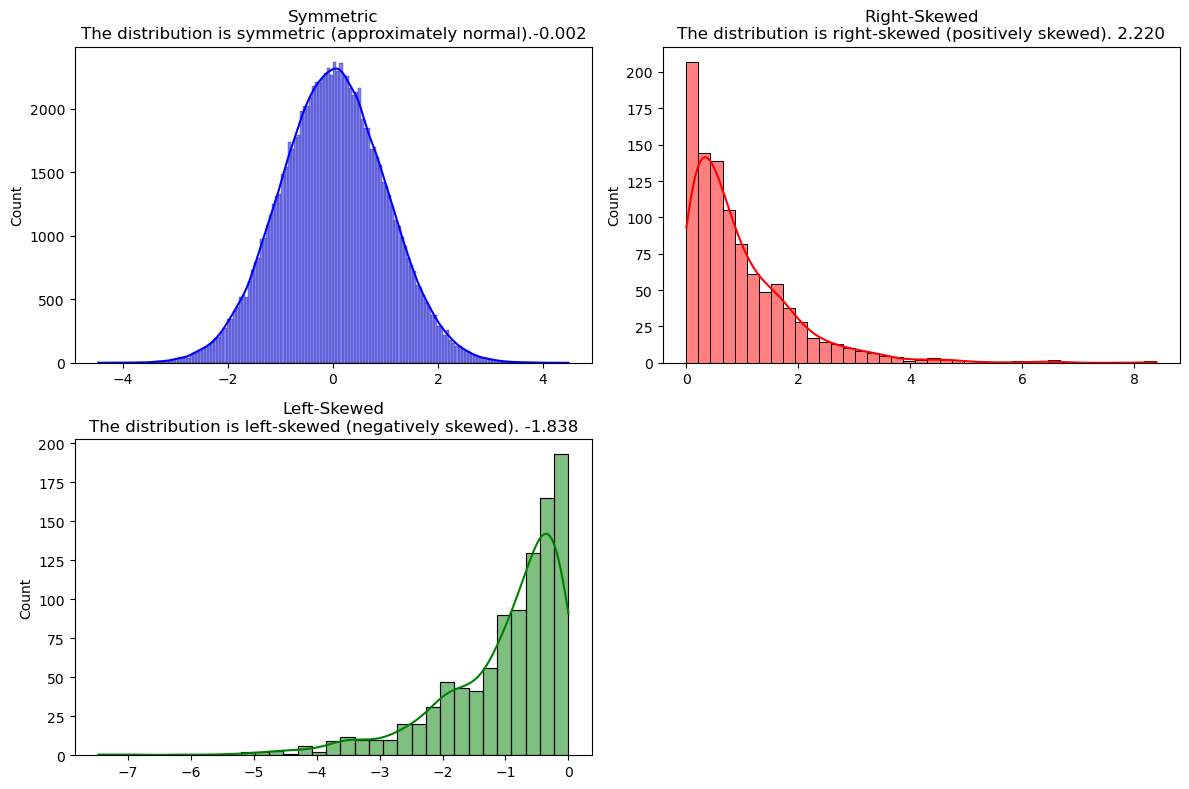

In [63]:
# plotto tutto su due righe e due colonne
import seaborn as sns
import matplotlib.pyplot as plt

# Create subplots (2 row, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot each distribution correctly
sns.histplot(data, kde=True, color="blue", ax=axes[0, 0])
axes[0, 0].set_title(f"Symmetric\n{check_distribution_skew(data)}")

sns.histplot(data_right, kde=True, color="red", ax=axes[0, 1])
axes[0, 1].set_title(f"Right-Skewed\n{check_distribution_skew(data_right)}")

sns.histplot(data_left, kde=True, color="green", ax=axes[1, 0])
axes[1, 0].set_title(f"Left-Skewed\n{check_distribution_skew(data_left)}")

# Remove empty plot (bottom right)
axes[1, 1].axis("off")

# Adjust layout and show
plt.tight_layout()
plt.show()

## Rifare esercizio
Andava fatto in maniera più corretta confrontando la media e la mediana, se corrispondono è simmetrica.
La vera condizione per stabilire se era simmetrica era controllare e confrontare media e mdiana
se media > mediana skew verso asimmetrica a destra

Se è simmetrica a skewness 0, ma quando otteniamo skew 0 non è detto che sia simmetrica.

In [1]:
### Soluzione insegnante
def determine_distribution_type(input_values):
    if input_values.mean() > input_values.median():
        return "Right-skewed"
    elif input_values.mean() < input_values.median():
        return "Left-skewed"
    else:
        return "Symmetric"

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## Exercise 2

2) A disease affects 2% of a population. The population is divided into three age groups:
* Young (50%): False positive rate 3%, sensitivity 95%.
* Middle-aged (30%): False positive rate 4%, sensitivity 90%.
* Elderly (20%): False positive rate 5%, sensitivity 85%.

N.B.
False positive rate: probability of a person testing positive when they do not have the disease.
Sensitivity/True positive rate: probability of a person testing positive when they have the disease.

If a random person from the population tests positive, what is the probability they actually have the disease?

### Ragionamento

Dovrò usare il teorema di **Bayes** per calcolare la probabilità di avere una malattia per una persona randomica appartenente alla popolazione che ha un test positivo:
$$P(D∣T_+) = \frac{P(T_+∣D)⋅P(D)}{P(T_+)}$$


So che per la popolazione la probabilità di avere una malattia (e quindi del complementare di non averla) è:
$$P(D) = 0.02$$
$$P(D^c) = 1 - 0.02 = 0.98$$

### Calcolo dei pezzi mancanti per completare la formula di bayes, inizio con il denominatore $P(T_+)$

Non capisco come sapere la prevalenza di malattia nelle fasce di età, quindi **per ipotesi dico che sarà distribuita uniformemente lasciando il 2%.**

So già i valori di ogni fascia di $TPR_(fascia)$ e $FPR_(fascia)$ e $P(D)$ (che lascio allo 0.02 per tutti). 

Per calcolare $P(T_+)$, ovverto la probabilità di avere un test positivo, devo calcolare tutte le probabilità di avere un test positivo per ogni fascia di età e sommarle (pesandole)

$P(T_+) = \sum_{i} P(T_+ | Fascia_i) \cdot P(Fascia_i)$

La **legge delle probabilità totali** afferma che se un evento può verificarsi in più modi disgiunti, la sua probabilità totale è la somma delle probabilità di ciascun modo, ponderata per la probabilità che quel modo si verifichi.

---

$P(T_+ | Fascia_i) = P(T_+ | D, Fascia_i) P(D) + P(T_+ | D^c, Fascia_i) P(D^c)$

Per ogni fascia calcolo una somma composta da **due termini**. Ogni termine è una probabilità congiunta (intersezione di eventi), in quanto stiamo calcolando la probabilità che i due eventi accadano simultaneamente, classicamente si scrive $P(A \cap B) = P(A | B) \cdot P(B)$ e si legge **la probabilità che accadano sia A che B è uguale alla probabilità che A accada dato che B è vero, moltiplicata per la probabilità che B accada.**

I due termini in dettaglio:
* $P(T_+ | D, Fascia_i)⋅P(D)$(**primo termine** rappresenta la probabilità che una persona giovane sia malata e ottenga un test positivo)
*  $P(T_+ | D^c, Fascia_i)⋅P(D^c)$ (**secondo termine** rappresenta la probabilità che una persona giovane non sia malata e ottenga comunque un test positivo.)

**Poiché questi due scenari coprono tutti i modi in cui una persona giovane può ottenere un test positivo**, la loro somma dà la probabilità complessiva che  $T_+$  si verifichi.


---


$P(T_+∣Young)= P(T_+ | D, Fascia_i)⋅P(D) + P(T_+ | D^c, Fascia_i)⋅P(D^c)= TPR_(young) * P(D) + FPR_(young) * P(D^c)$ 
$P(T_+∣Middle)= P(T_+ | D, Fascia_i)⋅P(D) + P(T_+ | D^c, Fascia_i)⋅P(D^c)= TPR_(middle) * P(D) + FPR_(middle) * P(D^c)$ 
$P(T_+∣Elder)= P(T_+ | D, Fascia_i)⋅P(D) + P(T_+ | D^c, Fascia_i)⋅P(D^c)= TPR_(elder) * P(D) + FPR_(elder) * P(D^c)$ 

---

Per calcolare quella **totale** le sommo con i pesi:
$P(T_+)=0.50*P(T_+∣Young)+0.30*P(T_+∣Middle)+0.20*P(T_+∣Elder)$

---

### Per calcolare l'ultimo tassello mancante della formula di bayes $P(T_+∣D)$:
La probabilità di ottenere un test positivo dato che una persona è malata dipende dalla distribuzione delle fasce di popolazione.

Qui il primo termine $P(T_+ | D, Fascia_i)$ è la probabilità che il test sia positivo se la persona è malata e appartiene alla fascia  $i$ e il secondo termine $P(Fascia_i)$ è la probabilità che una persona malata appartenga alla fascia  i.

$P(T_+∣D) = \sum_{i=1}^3P(T_+ | D, Fascia_i)*P(Fascia_i)$

ovvero sommo il prodotto dei TPR di ogni fascia con la percentuale di ogni fascia, in quanto:

$TPR = P(T_+|D) = \frac{TP}{TP+FN}$ e moltiplicandolo per la probabilità di appartenere alla fascia, ne pondero la sensibilità

---
### Focus TP E FN

* TP (True Positives): il numero di veri positivi, cioè i casi in cui il test è positivo e la persona è malata.
* FN (False Negatives): il numero di falsi negativi, cioè i casi in cui il test è negativo, ma la persona è effettivamente malata.

### TPR

Riflette la probabilità che unha persona di quella fascia, che è malata, ottenga un test positivo

---
### Totale
Qui ogni termine rappresenta la probabilità che una persona sia in quella fascia e abbia un test positivo. Poiché le fasce di età coprono tutti i casi possibili, possiamo sommare su tutte le fasce per ottenere la probabilità complessiva.

$P(T_+∣D)=(0.95*0.50)+(0.90*0.30)+(0.85*0.20)$

Avendo tutti i pezzi posso applicare il teorema di bayes...tutto molto bello su carta 📄, ora andiamo di codice 👩‍💻

### Coding

Procedo con le funzioni per trovare il denominatore della formula di bayes

In [9]:
# Funzione per calcolare la possibilità di risultare positivo per ogni fascia di età:

# Dizionario con TPR e FPR e percntuale per ogni fascia
rates = {
    'Young': {'TPR': 0.95, 'FPR': 0.03, 'percent':0.50},
    'Middle': {'TPR': 0.90, 'FPR': 0.04, 'percent':0.30},
    'Elder': {'TPR': 0.85, 'FPR': 0.05, 'percent':0.20}
}
# è il mio P(D)
prevalence = 0.02

# Funzione per calcolare P(T_+ | Fascia)
def calculate_positive_rate(fascia, prevalence):

    # Estrai TPR e FPR per la fascia di età selezionata
    TPR = rates[fascia]['TPR']
    FPR = rates[fascia]['FPR']
    
    # Calcola P(D) e P(D^c)
    P_D = prevalence  # Prevalenza della malattia il famoso 2% che mi ha fatto impazzire
    P_D_complement = 1 - P_D  # Complemento di P(D) (probabilità di non essere malato)
    
    # Calcola la probabilità di un risultato positivo dato che la persona appartiene alla fascia
    P_T_pos_given_fascia = TPR * P_D + FPR * P_D_complement
    return P_T_pos_given_fascia

# Funzione per calcolare il totale con i pesi P(T_+)
def calculate_total_positive_rate(prevalence):
    # Calcolare P(T_+ | Fascia) per ciascuna fascia
    P_T_pos_young = calculate_positive_rate('Young', prevalence)
    P_T_pos_middle = calculate_positive_rate('Middle', prevalence)
    P_T_pos_elder = calculate_positive_rate('Elder', prevalence)
    # print("P(T_+ | Young):", result_young)
    # print("P(T_+ | Middle):", result_middle)
    # print("P(T_+ | Elder):", result_elder)
    
    # Calcolare la probabilità totale di un risultato positivo
    P_T_pos = (rates['Young']['percent'] * P_T_pos_young + 
               rates['Middle']['percent'] * P_T_pos_middle + 
               rates['Elder']['percent'] * P_T_pos_elder)
    
    return P_T_pos


result_total = calculate_total_positive_rate(prevalence)

print("P(T_+):", result_total)


P(T_+): 0.05456


Ora calcolo l'ultimo pezzo
$P(T_+∣D)=(0.95*0.50)+(0.90*0.30)+(0.85*0.20)$


In [10]:
# Funzione per calcolare P(T_+ | D)
def calculate_positive_given_d():
    # Calcolare P(T_+ | D) come somma ponderata dei TPR per ogni fascia
    P_T_pos_given_D = sum(rates[fascia]['TPR'] * rates[fascia]['percent'] for fascia in rates)
    return P_T_pos_given_D

# Calcolare P(T_+ | D)
result = calculate_positive_given_d()

print("P(T_+ | D):", result)

P(T_+ | D): 0.915


Ora che ho tutti i valori finalmente posso usarli per la formula di Bayes

$$P(D∣T_+) = \frac{P(T_+∣D)⋅P(D)}{P(T_+)}$$

In [17]:
# Funzione per calcolare P(D | T_+)
def calculate_disease_given_positive(prevalence):
    # Applicare il Teorema di Bayes: P(D | T_+) = (P(T_+ | D) * P(D)) / P(T_+)
    P_D_given_T_pos = (calculate_positive_given_d() * prevalence) / calculate_total_positive_rate(prevalence)
    return P_D_given_T_pos

result_disease_given_positive = calculate_disease_given_positive(prevalence)

print(f"P(D | T_+):\novvero la probabilità che una persona abbia la malattia\ndato che il test è positivo è: {result_disease_given_positive * 100:.4f}%")

P(D | T_+):
ovvero la probabilità che una persona abbia la malattia
dato che il test è positivo è: 33.5411%


## Ho chiesto a GPT di semplificare il mio ragionamento....

In [7]:
def bayes_theorem(prior, sensitivity, evidence):
    """Calcola P(D | T+) usando la formula di Bayes"""
    return (sensitivity * prior) / evidence

# Dati del problema organizzati in un dizionario
population_groups = {
    "Young": {"fraction": 0.5, "sensitivity": 0.95, "false_positive": 0.03},
    "Middle-aged": {"fraction": 0.3, "sensitivity": 0.90, "false_positive": 0.04},
    "Elderly": {"fraction": 0.2, "sensitivity": 0.85, "false_positive": 0.05},
}

P_D = 0.02  # Probabilità di avere la malattia
P_not_D = 1 - P_D  # Probabilità di non avere la malattia

# Calcoliamo P(T+)
P_T = sum(
    (group["sensitivity"] * P_D + group["false_positive"] * P_not_D) * group["fraction"]
    for group in population_groups.values()
)

# Calcoliamo la sensibilità media ponderata e il false positive rate medio ponderato
weighted_sensitivity = sum(group["sensitivity"] * group["fraction"] for group in population_groups.values())
# weighted_false_positive = sum(group["false_positive"] * group["fraction"] for group in population_groups.values())

# Calcoliamo P(D | T+)
P_D_given_T = bayes_theorem(P_D, weighted_sensitivity, P_T)

print(f"La probabilità che una persona abbia la malattia dato che il test è positivo è: {P_D_given_T *100: .4f}")

La probabilità che una persona abbia la malattia dato che il test è positivo è:  33.5411


# Considerazioni
La versione di GPT usa la sensibilità media ponderata che non è esattamente $ P(T_+ \mid D)$ , ma una sua approssimazione nel caso in cui volessimo stimarla senza considerare la malattia.

A quanto pare la differenza chiave sta nella distribuzione della malattia tra le fasce. In questo caso visto che il 2% per ipotesi abbiamo detto che era distribuito uniformemente tra le fasce di età i valori risultano identici e io invece ho calcolato tutto come se potesse variare 

In [2]:
### soluzione insegnante

In [3]:
P_D = 0.02  # prior
P_not_D = 1 - P_D 

# Population distribution
P_Young = 0.5
P_Middle = 0.3
P_Elderly = 0.2

# Sensitivity (True positive rate)
P_Pos_given_D_Young = 0.95
P_Pos_given_D_Middle = 0.90
P_Pos_given_D_Elderly = 0.85

# False positive rates
P_Pos_given_not_D_Young = 0.03
P_Pos_given_not_D_Middle = 0.04
P_Pos_given_not_D_Elderly = 0.05

# Law of Total Probability
P_Pos = (
    P_Young * (P_Pos_given_D_Young * P_D + P_Pos_given_not_D_Young * P_not_D) +
    P_Middle * (P_Pos_given_D_Middle * P_D + P_Pos_given_not_D_Middle * P_not_D) +
    P_Elderly * (P_Pos_given_D_Elderly * P_D + P_Pos_given_not_D_Elderly * P_not_D)
)

# Applying Bayes' Theorem
P_D_given_Pos = (
    (P_Young * P_Pos_given_D_Young * P_D) +
    (P_Middle * P_Pos_given_D_Middle * P_D) +
    (P_Elderly * P_Pos_given_D_Elderly * P_D)
) / P_Pos

print(f"P(Disease | Positive Test) = {P_D_given_Pos:.3f}")

P(Disease | Positive Test) = 0.335
